In [1]:
import numpy as np
import matplotlib.pyplot as plt
import QST_core_processes as qst #type: ignore

### Generate data of states and associated measurements probabilities

In [2]:
N = 10000  # number of states
SEED = 14
n_qubits = 2

rhos, taus = qst.generate_dataset_of_states_and_probabilities(N, n_qubits, seed=SEED, p_pure=0.5, eps_pure=1e-5)
data = {'rhos': rhos, 'taus': taus}

### Setting up Projector Matrix and Simulating Shots

In [3]:
P = qst.build_projector_matrix(n_qubits)
P_noisy = qst.simulate_waveplate_misalignment(np.pi/6, P, n_qubits)

counts = []
n_shots = 100
for rho in data['rhos']:
    p = qst.get_measurement_probs_from_P_and_rho(rho, P_noisy, n_qubits)
    p_noisy = qst.simulate_interference_visibility(p, 0.97)
    counts.append(qst.retrieve_counts_from_n_shots_per_state(p_noisy, n_shots))

data['counts'] = np.stack(counts, axis=0) # easier to work with as a single array
data['P'] = P
data['shots'] = n_shots

In [4]:
qst.add_train_test_split_to_data(data, train_ratio=0.95, seed=SEED)
data_train = qst.get_split(data, "train")
data_test  = qst.get_split(data, "test")

This completes the 'setup' portion

For each set of shots data, must then:
- attempt to reconstruct rho using either stokes or Deep Learning
- (ensure consistency in storage)
- compare resulting density matrices with the actual density matrices stored originally

### Implementing Stokes Reconstruction

In [5]:
outputs = {}
outputs['stokes_rhos'] = qst.stokes_reconstruct_dataset(
    P = data['P'],
    counts = data_test['counts'],
    shots = data['shots'],
    n_qubits = n_qubits
)

### Implementing Feed Forward NN

In [6]:
# Naive Neural Network approach
nn_naive = qst.NN_Builder(
    n_qubits=n_qubits,
    model_type="mlp",
    loss_type="mse",
    target="rho",
    hidden_sizes=(256, 256, 256),
    dropout=0.1,
    lr=1e-3,
    batch_size=64,
    epochs=100
)

outputs['nn_naive_history'] = nn_naive.fit(data_train)
outputs['nn_naive_rhos'] = nn_naive.predict(data_test)


Epoch 1/100, Loss: 2.1562
Epoch 10/100, Loss: 0.6770
Epoch 20/100, Loss: 0.6264
Epoch 30/100, Loss: 0.5923
Epoch 40/100, Loss: 0.5668
Epoch 50/100, Loss: 0.5430
Epoch 60/100, Loss: 0.5274
Epoch 70/100, Loss: 0.5168
Epoch 80/100, Loss: 0.5083
Epoch 90/100, Loss: 0.4985
Epoch 100/100, Loss: 0.4901


In [7]:
# Physics-informed Neural Network approach
nn_phys = qst.NN_Builder(
    n_qubits=n_qubits,
    model_type="mlp",
    loss_type="fidelity",
    target="tau",
    hidden_sizes=(256, 256, 256),
    dropout=0.1,
    lr=1e-3,
    batch_size=64,
    epochs=100
)

outputs['nn_phys_history'] = nn_phys.fit(data_train)
outputs['nn_phys_rhos'] = nn_phys.predict(data_test)

Epoch 1/100, Loss: 63.6009
Epoch 10/100, Loss: 21.8388
Epoch 20/100, Loss: 19.6724
Epoch 30/100, Loss: 18.4998
Epoch 40/100, Loss: 17.6643
Epoch 50/100, Loss: 16.9269
Epoch 60/100, Loss: 16.4006
Epoch 70/100, Loss: 16.0507
Epoch 80/100, Loss: 15.7507
Epoch 90/100, Loss: 15.4461
Epoch 100/100, Loss: 15.1587


### Implementing CNNs

In [22]:
nn_cnn = qst.NN_Builder(
    n_qubits=n_qubits,
    model_type="cnn",
    loss_type="mse",
    target="rho",
    hidden_sizes=(64,),  
    dropout=0.1,
    cnn_channels=(8, 16),       
    cnn_kernel_size=3,          
    lr=1e-3,
    batch_size=64,
    epochs=100
)

outputs['nn_cnn_history'] = nn_cnn.fit(data_train)
outputs['nn_cnn_rhos'] = nn_cnn.predict(data_test)

Epoch 1/100, Loss: 2.5101
Epoch 10/100, Loss: 2.1489
Epoch 20/100, Loss: 2.1099
Epoch 30/100, Loss: 2.1036
Epoch 40/100, Loss: 2.1002
Epoch 50/100, Loss: 2.0988
Epoch 60/100, Loss: 2.0967
Epoch 70/100, Loss: 2.0962
Epoch 80/100, Loss: 2.0952
Epoch 90/100, Loss: 2.0940
Epoch 100/100, Loss: 2.0932


Naive CNN assumes "close" means close in the projector matrix \
We need to scan between measurements that are "close" in projector geometry

Options:
- Option 1, mix the frequencies before the CNN sees the grid. Take the input and apply a linear transform based on which projector measurements are geometrically similar
- Option 2, treat the 36 measurement settings as nodes in a graph, with adjacency weights derived from projector similarity. Build adjacency matrix and use graoh convolution

For the mixing of the frequencies, there are two options for the kernel change:

Overlap (softer mixing) - mix the 36 frequencies using a kernel derived from projector overlaps, $K_{ab} = Tr(P_aP_b)$. This biases the network to share information between similar measurement settings and then using the CNN

Fidelity (sharper more local mixing) - similar process but uses $|K_{ab} = Tr(P_aP_b)|^2$

In [23]:
nn_cnn_overlap = qst.NN_Builder(
    n_qubits=n_qubits,
    model_type="cnn",
    loss_type="mse",
    target="rho",
    hidden_sizes=(64,),
    dropout=0.1,
    cnn_channels=(8,16),
    cnn_kernel_size=3,
    cnn_kernel_type="proj_kernel",
    proj_kernel_metric="overlap",
    lr=1e-3,
    batch_size=64,
    epochs=100
)

outputs['cnn_overlap_history'] = nn_cnn_overlap.fit(data_train)
outputs['cnn_overlap_rhos'] = nn_cnn_overlap.predict(data_test)

Epoch 1/100, Loss: 2.5097
Epoch 10/100, Loss: 2.2446
Epoch 20/100, Loss: 2.1337
Epoch 30/100, Loss: 2.1277
Epoch 40/100, Loss: 2.1204
Epoch 50/100, Loss: 2.1022
Epoch 60/100, Loss: 2.0973
Epoch 70/100, Loss: 2.0946
Epoch 80/100, Loss: 2.0937
Epoch 90/100, Loss: 2.0930
Epoch 100/100, Loss: 2.0922


In [24]:
nn_cnn_fidelity = qst.NN_Builder(
    n_qubits=n_qubits,
    model_type="cnn",
    loss_type="mse",
    target="rho",
    hidden_sizes=(64,),
    dropout=0.1,
    cnn_channels=(8,16),
    cnn_kernel_size=3,
    cnn_kernel_type="proj_kernel",
    proj_kernel_metric="fidelity",
    lr=1e-3,
    batch_size=64,
    epochs=100
)

outputs['cnn_fidelity_history'] = nn_cnn_fidelity.fit(data_train)
outputs['cnn_fidelity_rhos'] = nn_cnn_fidelity.predict(data_test)

Epoch 1/100, Loss: 2.5098
Epoch 10/100, Loss: 2.2415
Epoch 20/100, Loss: 2.1299
Epoch 30/100, Loss: 2.1239
Epoch 40/100, Loss: 2.1219
Epoch 50/100, Loss: 2.1203
Epoch 60/100, Loss: 2.1193
Epoch 70/100, Loss: 2.1158
Epoch 80/100, Loss: 2.1053
Epoch 90/100, Loss: 2.0988
Epoch 100/100, Loss: 1.9621


### Analysis

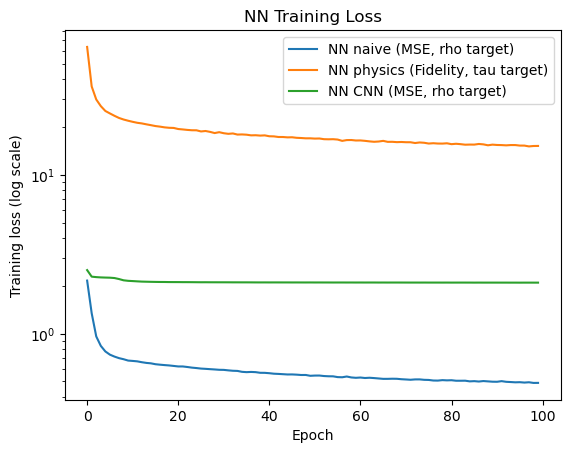

In [25]:
plt.figure()
plt.semilogy(outputs["nn_naive_history"]["loss"], label="NN naive (MSE, rho target)")
plt.semilogy(outputs["nn_phys_history"]["loss"], label="NN physics (Fidelity, tau target)")
plt.semilogy(outputs["nn_cnn_history"]["loss"], label="NN CNN (MSE, rho target)")
plt.xlabel("Epoch")
plt.ylabel("Training loss (log scale)")
plt.title("NN Training Loss")
plt.legend()
plt.show()

In [26]:
# Compute fidelities

true_rhos = data_test["rhos"]

def fidelities_vs_truth(pred_rhos):
    return np.array([qst.fidelity(true_rhos[k], pred_rhos[k]) for k in range(len(true_rhos))])

F_stokes = fidelities_vs_truth(outputs["stokes_rhos"])
F_naive  = fidelities_vs_truth(outputs["nn_naive_rhos"])
F_phys   = fidelities_vs_truth(outputs["nn_phys_rhos"])
F_cnn    = fidelities_vs_truth(outputs["nn_cnn_rhos"])
F_cnn_overlap = fidelities_vs_truth(outputs["cnn_overlap_rhos"])
F_cnn_fidelity = fidelities_vs_truth(outputs["cnn_fidelity_rhos"])

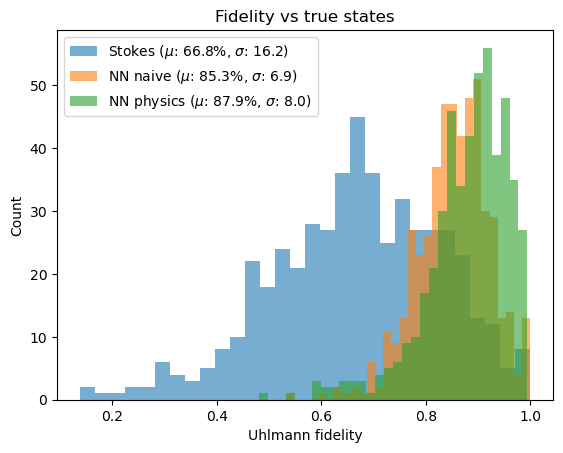

Mean fidelities:
  Stokes: 0.6677858461627059 std: 0.16163603470785534
  Naive : 0.8526552551993364 std: 0.06935660501071214
  Phys  : 0.8787356701941685 std: 0.07967118604297985
  CNN   : 0.5339761514465772 std: 0.2399831400579603


In [27]:
plt.figure()
plt.hist(F_stokes, bins=30, alpha=0.6, label=rf"Stokes ($\mu$: {(F_stokes.mean()*100):.1f}%, $\sigma$: {(F_stokes.std()*100):.1f})")
plt.hist(F_naive,  bins=30, alpha=0.6, label=rf"NN naive ($\mu$: {F_naive.mean()*100:.1f}%, $\sigma$: {(F_naive.std()*100):.1f})")
plt.hist(F_phys,   bins=30, alpha=0.6, label=rf"NN physics ($\mu$: {F_phys.mean()*100:.1f}%, $\sigma$: {(F_phys.std()*100):.1f})")
# plt.hist(F_cnn,    bins=30, alpha=0.6, label=rf"NN CNN ($\mu$: {F_cnn.mean()*100:.1f}%, $\sigma$: {(F_cnn.std()*100):.1f})")

plt.xlabel("Uhlmann fidelity")
plt.ylabel("Count")
plt.title("Fidelity vs true states")
plt.legend(loc='upper left')
plt.show()


print("Mean fidelities:")
print("  Stokes:", F_stokes.mean(), "std:", F_stokes.std())
print("  Naive :", F_naive.mean(),  "std:", F_naive.std())
print("  Phys  :", F_phys.mean(),   "std:", F_phys.std())
print("  CNN   :", F_cnn.mean(),    "std:", F_cnn.std())

In [28]:
# Test NN outputs on PSD in states: are they physical

naive_rhos = outputs["nn_naive_rhos"]
phys_rhos = outputs["nn_phys_rhos"]

def is_physical(rho):
    # Check if rho is Hermitian
    if not np.allclose(rho, rho.conj().T):
        return False
    
    # Check if rho is positive semidefinite (PSD)
    eigenvalues = np.linalg.eigvalsh(rho)
    if np.any(eigenvalues < -1e-8):  # Allow for some numerical tolerance
        return False
    
    # Check if trace of rho is 1
    if not np.isclose(np.trace(rho), 1):
        return False
    
    return True

nn_naive_physicality = np.array([is_physical(rho) for rho in naive_rhos])
nn_phys_physicality = np.array([is_physical(rho) for rho in phys_rhos])

print("Naive NN physicality:", nn_naive_physicality.mean())
print("Physics-informed NN physicality:", nn_phys_physicality.mean())
print("CNN NN physicality:", np.array([is_physical(rho) for rho in outputs["nn_cnn_rhos"]]).mean())

Naive NN physicality: 0.696
Physics-informed NN physicality: 0.992
CNN NN physicality: 1.0


### CNN Comparison

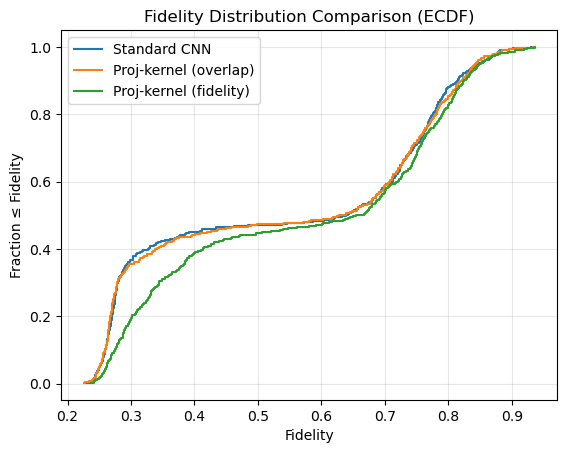

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def ecdf(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

plt.figure()

for label, F in [
    ("Standard CNN", F_cnn),
    ("Proj-kernel (overlap)", F_cnn_overlap),
    ("Proj-kernel (fidelity)", F_cnn_fidelity),
]:
    x, y = ecdf(F)
    plt.step(x, y, where="post", label=label)

plt.xlabel("Fidelity")
plt.ylabel("Fraction ≤ Fidelity")
plt.title("Fidelity Distribution Comparison (ECDF)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
def summarize(name, F):
    F = np.asarray(F)
    return {
        "method": name,
        "mean": float(np.mean(F)),
        "std": float(np.std(F, ddof=1)),
        "median": float(np.median(F)),
        "p10": float(np.quantile(F, 0.10)),
        "p90": float(np.quantile(F, 0.90)),
    }

for s in [
    summarize("Standard", F_cnn),
    summarize("Overlap", F_cnn_overlap),
    summarize("Fidelity", F_cnn_fidelity),
]:
    print(s)

{'method': 'Standard', 'mean': 0.5339761514465772, 'std': 0.240223483773738, 'median': 0.6397506522902839, 'p10': 0.2595100393188756, 'p90': 0.8152634184864251}
{'method': 'Overlap', 'mean': 0.5356511464221824, 'std': 0.23987421985592114, 'median': 0.6318269199677291, 'p10': 0.25931081231901115, 'p90': 0.821425251231789}
{'method': 'Fidelity', 'mean': 0.5644270378169067, 'std': 0.22552692853690295, 'median': 0.6559872332988401, 'p10': 0.2746779098443005, 'p90': 0.8243939528081344}
